# IHotspotVolume
Calculates along-track volumetric contributions from a hotspot trace using bathymetry, age data, and gravity model inputs.

Each cell can be run independently after the **Imports & Setup** cell has been run once.

## Imports & Setup

In [25]:
%load_ext autoreload
%autoreload 2

import os
import shutil
import subprocess
import numpy as np
import matplotlib
# matplotlib.use('TkAgg')  # change to 'Agg' if no display
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.ticker as ticker
import pandas as pd

from grd_utils import grdread2
from IHotVol_PickMask import IHotVol_PickMask
from IHotVol_ORS import IHotVol_ORS
from IHotVol_Track import IHotVol_Track
from IHotVol_PickEdifice import IHotVol_PickEdifice
from IHotVol_Airy import IHotVol_Airy
from IHotVol_Flexure import IHotVol_Flexure
from IHotVol_GravForward import IHotVol_GravForward
from IHotVol_FAAgetResidual import IHotVol_FAAgetResidual
from IHotVol_Underplating import IHotVol_Underplating
from IHotVol_SampleVolGrids import IHotVol_SampleVolGrids
from IHotVol_VolumeSlices import IHotVol_VolumeSlices
from IHotVol_AgeVolPlot import IHotVol_AgeVolPlot
from IHotVol_Spectral import IHotVol_Spectral

def run(cmd):
    """Run a GMT shell command, suppressing warnings."""
    env = os.environ.copy()
    env['GMT_VERBOSE'] = 'e'
    env['PATH'] = '/opt/homebrew/bin:/usr/local/bin:' + env.get('PATH', '')
    subprocess.run(cmd + ' 2>/dev/null', shell=True, check=True, env=env)

def load_gmt_table(filename):
    """Load a GMT multisegment table, replacing '>' header lines with NaN rows."""
    rows = []
    ncols = None
    with open(filename, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if ncols is not None:
                    rows.append([np.nan] * ncols)
            else:
                vals = [float(v) if v != 'NaN' else np.nan for v in line.split()]
                if ncols is None:
                    ncols = len(vals)
                rows.append(vals)
    return np.array(rows)

print('Imports done.')

try:
    from matplotlib_inline.backend_inline import InlineBackend as _IB
    _IB.instance().print_figure_kwargs.update(
        {'facecolor': 'white', 'edgecolor': 'white'})
except Exception:
    pass
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor':  'white',
    'axes.edgecolor':   'black', 'axes.labelcolor': 'black',
    'xtick.color':      'black', 'ytick.color':     'black',
    'text.color':       'black', 'savefig.facecolor':'white',
    'grid.color':       '#cccccc',
})


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports done.


## Parameters & Paths

In [17]:
# Grid file (name without extension)
grdname = 'Balleny'
grdfile = grdname + '.grd'

# AGES file  [lon, lat, age_Ma]
AGES = np.loadtxt('AGES.txt')

# Global grid paths
SFLagegrd = './global/infl.age.3.6.grd'
SEDthckgrd = './global/sedthick_world_v2.grd'
WGMFAAgrd = './global/WGM2012_Freeair_ponc_2min_360.grd'

# Adjust AGES longitudes if needed
AGES[AGES[:, 0] < 0, 0] += 360

# Bathy corners
NE = [np.max(AGES[:, 1]) + 5, np.max(AGES[:, 0]) + 5]
SW = [np.min(AGES[:, 1]) - 5, np.min(AGES[:, 0]) - 5]

# ORS filter parameters
minW  = 100
maxW  = 600
intW  = 100
level = 300
subaq = 1
mask  = 0

# Flexure model inputs
rho_c   = 2800
rho_w   = 1035
rho_m   = 3300
rho_i   = 2400
rho_u   = 3000
E       = 2e23
v       = 0.25
g       = 9.8
cr_thck = 7000
T_elas  = 400
T_mant  = 1300
kappa   = 1e-6

print('Parameters set.')

Parameters set.


## Step 1 — Get Grid File

In [4]:
if os.path.exists('CORNERS.xy'):
    os.remove('CORNERS.xy')
with open('CORNERS.xy', 'w') as f:
    f.write(f"{grdname},{NE[1]},{NE[0]},{SW[1]},{SW[0]}\n")

if not os.path.exists(grdfile):
    shutil.copy('./dependencies/WGET_BATHY.sh', './')
    run('bash WGET_BATHY.sh')
else:
    print(f'{grdfile} already exists, skipping download.')

run(f'gmt grdsample {grdfile} -R{grdfile} -I2m+e -G{grdfile}')
X, Y, Z = grdread2(grdfile)
print("X Shape", X.shape, "Y Shape", Y.shape, "Z Shape", Z.shape)
print(f'Grid loaded: {Z.shape[1]} x {Z.shape[0]} nodes')

Balleny.grd already exists, skipping download.
X Shape (553,) Y Shape (500,) Z Shape (500, 553)
Grid loaded: 553 x 500 nodes


## Step 2 — Mask (optional)

In [5]:
if mask == 1:
    XpolyM, YpolyM, INPmask = IHotVol_PickMask(grdfile)
else:
    print('mask=0, skipping.')

mask=0, skipping.


## Step 3 — Optimised Residual Separation (ORS)

In [7]:
if mask == 1:
    shutil.copy('./dependencies/RR-Sep_mask.sh', './')
    shutil.copy('./dependencies/RR-Sep-single_mask.sh', './')
else:
    shutil.copy('./dependencies/RR-Sep.sh', './')
    shutil.copy('./dependencies/RR-Sep-single.sh', './')

if not os.path.exists('ORStable.txt'):
    ORS_L, region = IHotVol_ORS(grdfile, X, Y, Z, minW, maxW, intW, level, mask)
    print(f'ORS complete. Optimal filter wavelength: {ORS_L[0]} km')
else:
    ORS = np.loadtxt('ORStable.txt')
    ORS_L = ORS[ORS[:, 4] == ORS[:, 4].max(), :]
    if ORS_L.ndim == 2:
        ORS_L = ORS_L[0]
    region = (f'-R{np.ceil(X.min()) + 0.05:.4f}/{np.floor(X.max()) - 0.05:.4f}'
              f'/{np.ceil(Y.min()) + 0.05:.4f}/{np.floor(Y.max()) - 0.05:.4f}')
    print(f'ORStable.txt exists. Loaded filter wavelength: {ORS_L[0]} km')

ORStable.txt exists. Loaded filter wavelength: 600.0 km


## ORS Output: Regional & Residual Bathymetry

After the Optimised Residual Separation (ORS), the observed bathymetry is decomposed into two components:

### Regional Bathymetry (`_regional.grd`)
The **broad, slowly-varying seafloor background** — representing the deep oceanic plate and lithospheric flexure at large scales. It is produced by applying the optimal-width Directional Median (DiM) filter to the raw bathymetry. It captures features much larger than the volcanic edifice itself, such as the general depth trend of the ocean floor and long-wavelength flexural moats.

### Residual Bathymetry (`_residual.grd`)
The **local anomaly** obtained by subtracting the regional from the observed bathymetry:

> **Residual = Observed − Regional**

Positive residual values represent volcanic edifices (seamounts, islands) that rise **above** the regional seafloor. Negative values indicate topographic lows such as flexural moats surrounding the edifice. The residual is the key input for all downstream volume calculations, gravity modelling, and isostatic analysis in this workflow.

The optimal filter wavelength (shown in the plot title) was selected by the ORS algorithm as the width that **maximises the mean residual amplitude**, ensuring the edifice signal is cleanly isolated from the regional background.## Step 3 — Optimised Residual Separation (ORS)

Shape of residual.grd  : (448, 508)
Shape of regional.grd  : (448, 508)


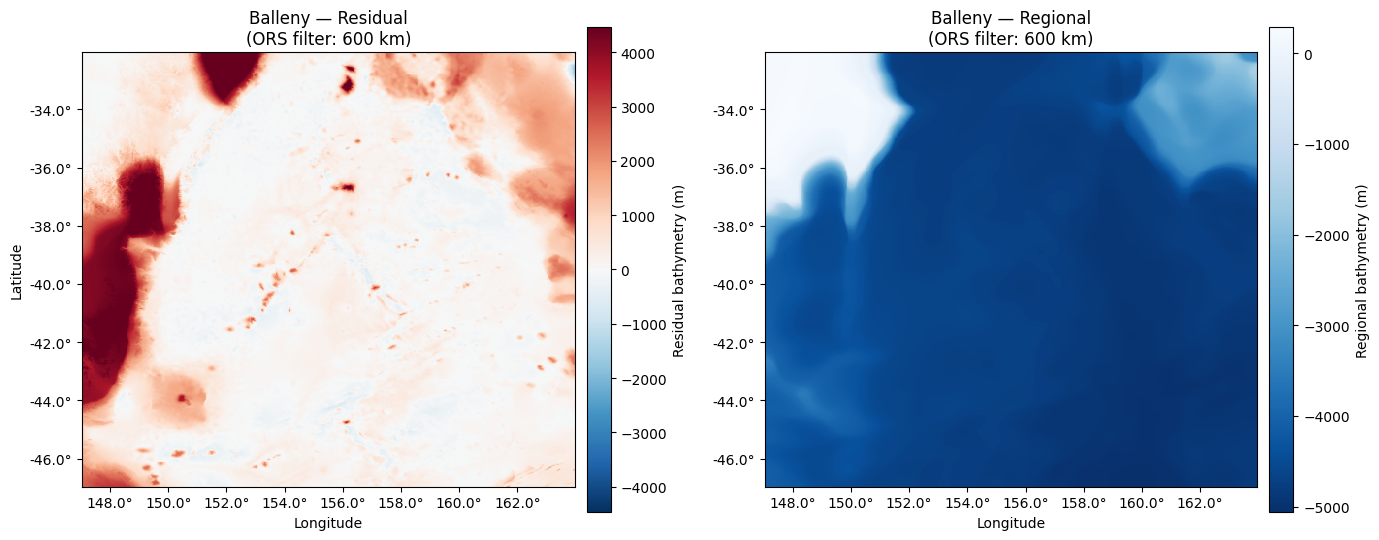

Residual range : -1599 to 6221 m
Regional range : -5056 to 287 m


In [26]:
# ── Plot ORS residual and regional grids ─────────────────────────────────────
Xres, Yres, Zres = grdread2(f'{grdfile}_residual.grd')
Xreg, Yreg, Zreg = grdread2(f'{grdfile}_regional.grd')

print('Shape of residual.grd  :', Zres.shape)
print('Shape of regional.grd  :', Zreg.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Residual ─────────────────────────────────────────────────────────────────
ax = axes[0]
vmax_res = np.nanpercentile(np.abs(Zres), 98)
im0 = ax.pcolormesh(Xres, Yres, Zres,
                    cmap='RdBu_r',
                    vmin=-vmax_res, vmax=vmax_res,
                    shading='auto')
cb0 = fig.colorbar(im0, ax=ax, pad=0.02, shrink=0.85)
cb0.set_label('Residual bathymetry (m)', fontsize=10)
ax.set_title(f'{grdname} — Residual\n(ORS filter: {ORS_L[0]:.0f} km)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f°'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f°'))
ax.set_aspect('equal')

# ── Regional ─────────────────────────────────────────────────────────────────
ax = axes[1]
im1 = ax.pcolormesh(Xreg, Yreg, Zreg,
                    cmap='Blues_r',
                    shading='auto')
cb1 = fig.colorbar(im1, ax=ax, pad=0.02, shrink=0.85)
cb1.set_label('Regional bathymetry (m)', fontsize=10)
ax.set_title(f'{grdname} — Regional\n(ORS filter: {ORS_L[0]:.0f} km)', fontsize=12)
ax.set_xlabel('Longitude')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f°'))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f°'))
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'results/{grdname}_ORS_residual_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Residual range : {np.nanmin(Zres):.0f} to {np.nanmax(Zres):.0f} m')
print(f'Regional range : {np.nanmin(Zreg):.0f} to {np.nanmax(Zreg):.0f} m')

## Step 4 — Hotspot Age Track

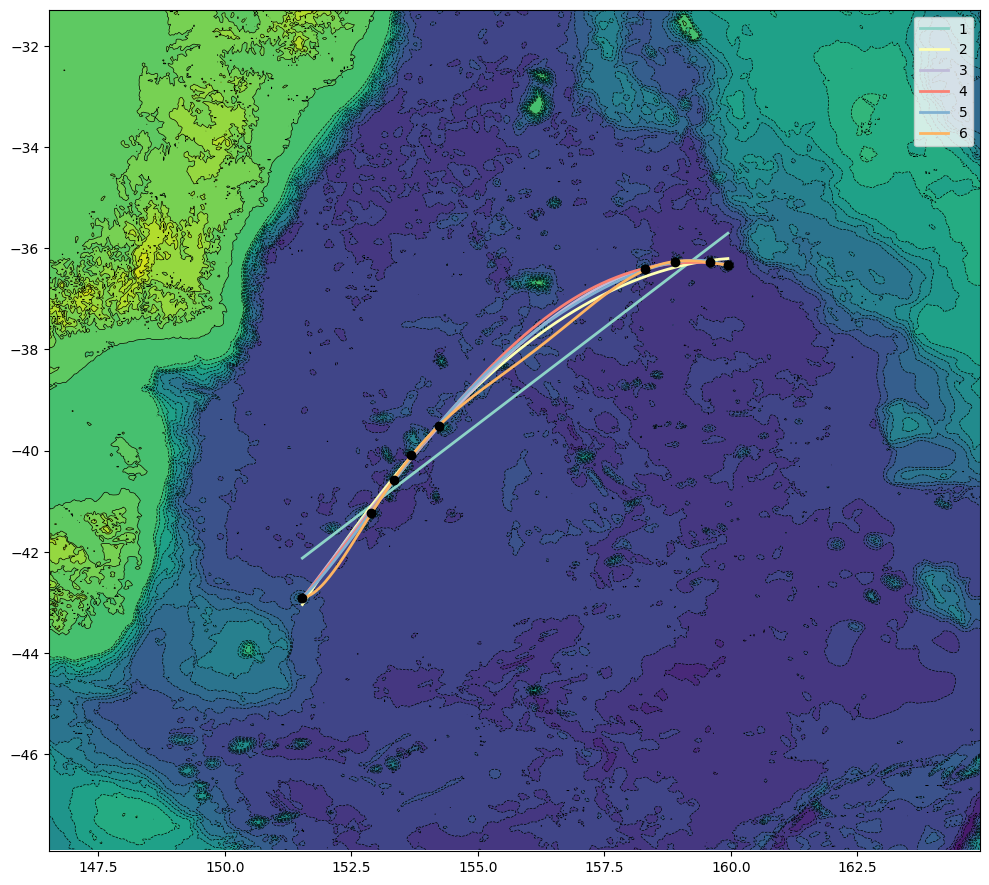

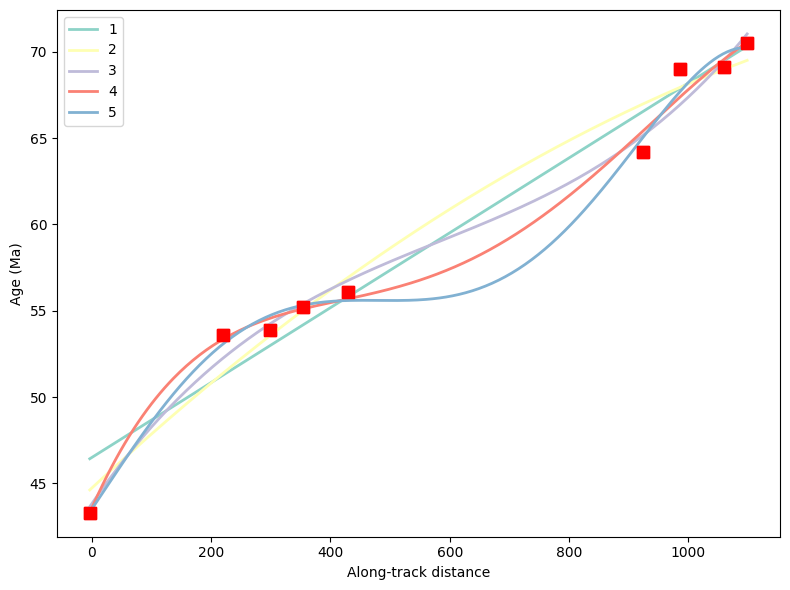

Track built: 55 points


In [27]:
HSPT_TRK, AGES, pA, TMPTRK = IHotVol_Track(AGES, X, Y, Z, grdfile, SFLagegrd)
print(f'Track built: {len(HSPT_TRK)} points')

## Step 5 — Pick Edifice

In [28]:
%matplotlib tk
Xpoly, Ypoly, INP = IHotVol_PickEdifice(grdfile, AGES)
print('Edifice picked.')

Please click to draw a polygon around the edifice of interest.
Press ENTER when finished.
You picked this material as your volcanic edifice.
Edifice picked.


## Step 6 — Airy Isostasy

So for every 1 km of volcanic edifice above the seafloor, the crust root sinks ~3.53 km into the mantle beneath it.

In [29]:
IHotVol_Airy(grdfile, rho_c, rho_w, rho_m)
print('Airy compensation calculated.')

Airy compensation calculated.


## Step 7 — Flexure Calculation

In [30]:
ii = 1
Xflx, Yflx, Zflx = IHotVol_Flexure(
    f'{grdfile}_edifice.grd', rho_c, rho_w, rho_m, rho_i,
    T_elas, T_mant, kappa, HSPT_TRK, grdfile, ii)
print(f'Flexure grid computed (iteration {ii}).')

Flexure grid computed (iteration 1).


Shape of edifice.grd: (553,) (500,) (500, 553)
Shape of flexure.grd: (553,) (500,) (500, 553)


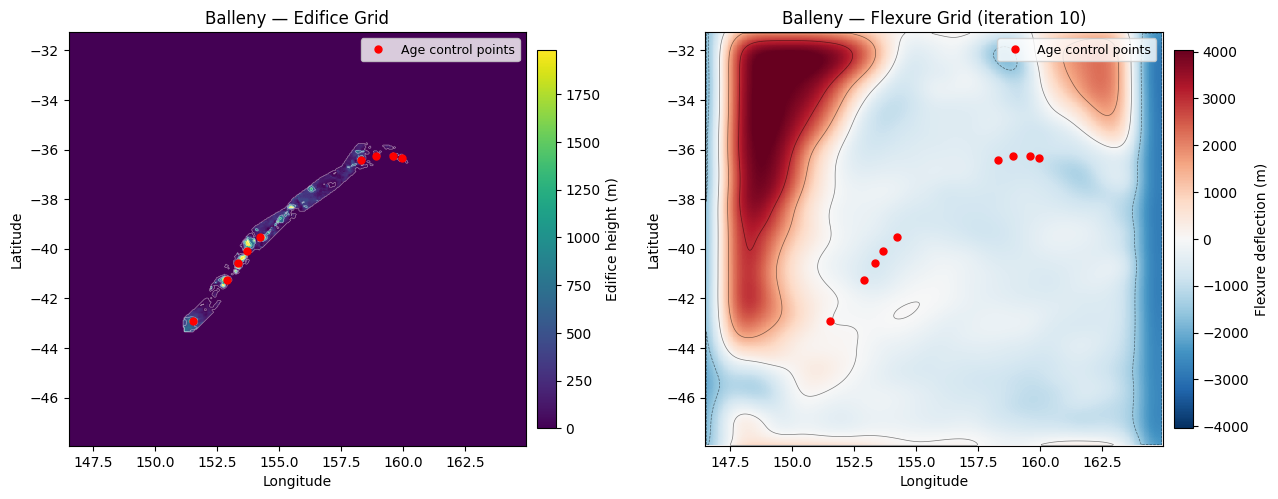

Edifice height range : 0 – 2808 m
Flexure range        : -2908 – 4366 m


In [42]:
# ── Plot edifice and flexure grids side by side ───────────────────────────────

%matplotlib inline
Xe, Ye, Ze   = grdread2(f'{grdfile}_edifice.grd')
Xfl, Yfl, Zfl = grdread2(f'flexure.DENAN.{ii}.grd')

print('Shape of edifice.grd:', Xe.shape, Ye.shape, Ze.shape)
print('Shape of flexure.grd:', Xfl.shape, Yfl.shape, Zfl.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Edifice ──────────────────────────────────────────────────────────────────
ax = axes[0]
vmax_e = np.nanpercentile(Ze[Ze > 0], 98)
im0 = ax.pcolormesh(Xe, Ye, Ze, cmap='viridis', vmin=0, vmax=vmax_e, shading='auto')
cb0 = fig.colorbar(im0, ax=ax, pad=0.02, shrink=0.85)
cb0.set_label('Edifice height (m)', fontsize=10)
ax.contour(Xe, Ye, Ze, levels=6, colors='white', linewidths=0.5, alpha=0.5)
ax.plot(AGES[:, 0], AGES[:, 1], 'ro', markersize=5, label='Age control points')
ax.set_title(f'{grdname} — Edifice Grid', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')

# ── Flexure ───────────────────────────────────────────────────────────────────
ax = axes[1]
vmax_f = np.nanpercentile(np.abs(Zfl[~np.isnan(Zfl)]), 98)
im1 = ax.pcolormesh(Xfl, Yfl, Zfl, cmap='RdBu_r', vmin=-vmax_f, vmax=vmax_f, shading='auto')
cb1 = fig.colorbar(im1, ax=ax, pad=0.02, shrink=0.85)
cb1.set_label('Flexure deflection (m)', fontsize=10)
ax.contour(Xfl, Yfl, Zfl, levels=6, colors='k', linewidths=0.5, alpha=0.5)
ax.plot(AGES[:, 0], AGES[:, 1], 'ro', markersize=5, label='Age control points')
ax.set_title(f'{grdname} — Flexure Grid (iteration {ii})', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(f'results/{grdname}_edifice_flexure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Edifice height range : {np.nanmin(Ze[Ze>0]):.0f} – {np.nanmax(Ze):.0f} m')
print(f'Flexure range        : {np.nanmin(Zfl):.0f} – {np.nanmax(Zfl):.0f} m')

## Step 8 — Gravity Forward Model
The goal is to compute a synthetic (predicted) gravity field from the known physical structure, so it can later be compared against the observed FAA gravity (Step 9). The difference tells you how much extra mass (underplating) is missing from your model.

SYNTH.grav.grd = flex.moho + rock + thermal + sed

In [32]:
os.makedirs('gravmodel', exist_ok=True)
sedcutgrdfile    = 'gravmodel/sedcut.DENAN.plusone.grd'
subaerialgrdfile = 'gravmodel/subair.DENAN.grd'
mohoflexgrdfile  = f'flexure.DENAN.{ii}.grd'
denangrdfile     = f'gravmodel/{grdfile}.DENAN.grd'
edificegrdfile   = f'{grdfile}_edifice.grd'

run(f'gmt grdmath {grdfile} 0 MUL = zerogrdfile.grd')
run(f'gmt grdsample {grdfile} -R{edificegrdfile} -G{denangrdfile}')
run(f'gmt grdmath {denangrdfile} 0 DENAN = {denangrdfile}')
run(f'gmt grdmath {grdfile} 0 GT {grdfile} MUL = gravmodel/subair.grd')
run(f'gmt grdmath gravmodel/subair.grd 0 DENAN = {subaerialgrdfile}')
run(f'gmt grdsample {SEDthckgrd} -R{grdfile} -Ggravmodel/sedcut.{grdfile}')
run(f'gmt grdmath gravmodel/sedcut.{grdfile} 0 DENAN 1 {grdfile} ADD  = {sedcutgrdfile}')
run(f'gmt grdmath {sedcutgrdfile} 0 DENAN = {sedcutgrdfile}')

XgMod, YgMod, ZgMod = IHotVol_GravForward(
    grdfile, denangrdfile, edificegrdfile, sedcutgrdfile,
    subaerialgrdfile, mohoflexgrdfile,
    rho_c, rho_w, rho_m, rho_i, kappa, INP, ORS_L, subaq)
print('Forward gravity model computed.')

Forward gravity model computed.


## Step 9 — FAA Residual

In [33]:
XResG, YResG, ZResG = IHotVol_FAAgetResidual(ORS_L, WGMFAAgrd, mask, subaq)

INPold = INP.copy()
XResGmesh, YResGmesh = np.meshgrid(XResG, YResG)
poly_path = Path(np.column_stack([Xpoly, Ypoly]))
pts = np.column_stack([XResGmesh.ravel(), YResGmesh.ravel()])
INP = poly_path.contains_points(pts).reshape(XResGmesh.shape)

grav_resid = np.sqrt(float(np.sum((INP * ZResG) ** 2)))
print(f'FAA residual computed. Gravity residual = {grav_resid:.4f}')

FAA residual computed. Gravity residual = 2440.1756


(448, 508) (448, 508)


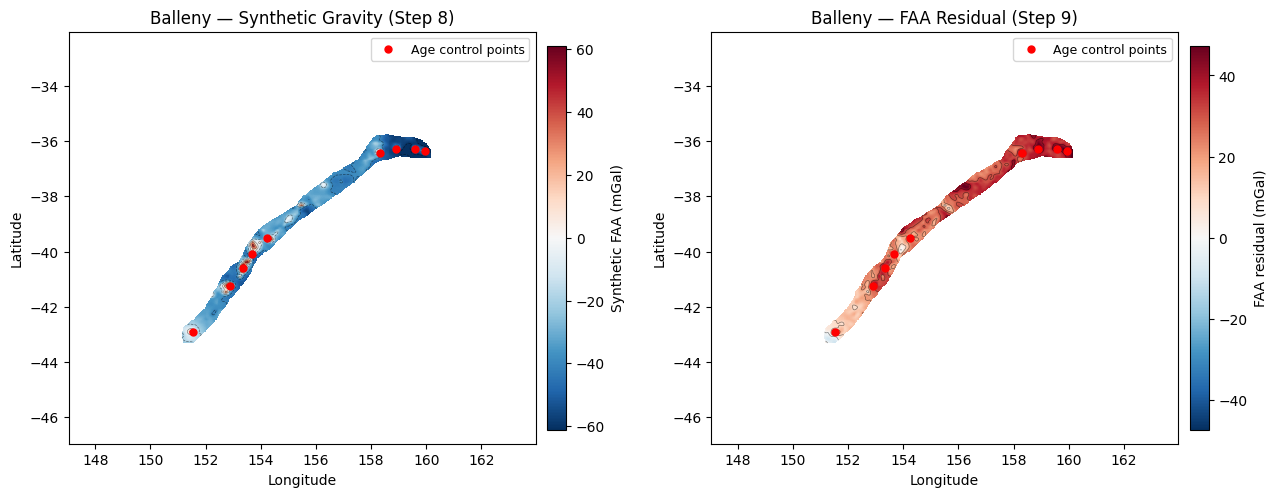

Synthetic gravity range : -67.27 to 64.73 mGal
FAA residual range      : -9.08 to 53.23 mGal
Gravity misfit (RMS)    : 2440.1756


In [37]:
# ── Plot synthetic gravity (Step 8) and FAA residual (Step 9) side by side ───
%matplotlib inline

print(ZgMod.shape, ZResG.shape)

# Resize INP to match each grid using polygon path
def apply_inp(X, Y, Xpoly, Ypoly):
    """Recompute INP mask at the resolution of grid X, Y."""
    Xm, Ym = np.meshgrid(X, Y)
    pts = np.column_stack([Xm.ravel(), Ym.ravel()])
    mask = Path(np.column_stack([Xpoly, Ypoly])).contains_points(pts)
    return mask.reshape(Xm.shape)

INP_gMod = apply_inp(XgMod, YgMod, Xpoly, Ypoly)
INP_ResG = apply_inp(XResG, YResG, Xpoly, Ypoly)

ZgMod_masked = np.where(INP_gMod, ZgMod, np.nan)
ZResG_masked = np.where(INP_ResG, ZResG, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# ── Synthetic gravity ─────────────────────────────────────────────────────────
ax = axes[0]
vmax_g = np.nanpercentile(np.abs(ZgMod_masked[~np.isnan(ZgMod_masked)]), 98)
im0 = ax.pcolormesh(XgMod, YgMod, ZgMod_masked,
                    cmap='RdBu_r', vmin=-vmax_g, vmax=vmax_g, shading='auto')
cb0 = fig.colorbar(im0, ax=ax, pad=0.02, shrink=0.85)
cb0.set_label('Synthetic FAA (mGal)', fontsize=10)
ax.contour(XgMod, YgMod, ZgMod_masked, levels=6,
           colors='k', linewidths=0.5, alpha=0.5)
ax.plot(AGES[:, 0], AGES[:, 1], 'ro', markersize=5, label='Age control points')
ax.set_title(f'{grdname} — Synthetic Gravity (Step 8)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')

# ── FAA residual ──────────────────────────────────────────────────────────────
ax = axes[1]
vmax_r = np.nanpercentile(np.abs(ZResG_masked[~np.isnan(ZResG_masked)]), 98)
im1 = ax.pcolormesh(XResG, YResG, ZResG_masked,
                    cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r, shading='auto')
cb1 = fig.colorbar(im1, ax=ax, pad=0.02, shrink=0.85)
cb1.set_label('FAA residual (mGal)', fontsize=10)
ax.contour(XResG, YResG, ZResG_masked, levels=6,
           colors='k', linewidths=0.5, alpha=0.5)
ax.plot(AGES[:, 0], AGES[:, 1], 'ro', markersize=5, label='Age control points')
ax.set_title(f'{grdname} — FAA Residual (Step 9)', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(f'results/{grdname}_synth_grav_faa_residual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Synthetic gravity range : {np.nanmin(ZgMod_masked):.2f} to {np.nanmax(ZgMod_masked):.2f} mGal')
print(f'FAA residual range      : {np.nanmin(ZResG_masked):.2f} to {np.nanmax(ZResG_masked):.2f} mGal')
print(f'Gravity misfit (RMS)    : {grav_resid:.4f}')

## Step 10 — Underplating (first estimate)

In [38]:
Xg, Yg, finaltopoinverse = IHotVol_Underplating(
    Xflx, Yflx, Zflx, XResG, YResG, ZResG, ii, grdfile, ORS_L, 1e-5)
print(f'Iteration {ii}: First underplating estimate done.')

  Underplating iter 2, rms = 0.236693 km
  Underplating iter 3, rms = 0.066564 km
  Underplating iter 4, rms = 0.049719 km
  Underplating iter 5, rms = 0.036481 km
  Underplating iter 6, rms = 0.028658 km
  Underplating iter 7, rms = 0.023085 km
  Underplating iter 8, rms = 0.018929 km
  Underplating iter 9, rms = 0.015761 km
  Underplating iter 10, rms = 0.013263 km
Underplating stopped at iteration 10, rms = 0.013263 km
Iteration 1: First underplating estimate done.


## Step 11 — Iterative Flexure / Underplating

In [39]:
residDiff = [1e10]
ii = 1
# Max iterations for flexure/underplating loop
max_iterations = 10

while residDiff[ii - 1] > 0.0001 and ii < max_iterations:
    ii += 1
    print(f'Iteration {ii} / {max_iterations}')

    run(f'gmt grdsample Uplate.{ii-1}.grd -R{grdfile}_edifice.grd -GUplate.{ii-1}.grd')
    run(f'gmt grdmath Uplate.{ii-1}.grd Uplate.{ii-1}.grd LOWER SUB = Uplate.{ii-1}.grd')
    run((f'gmt grdmath {grdfile}_edifice.grd {rho_c - rho_w} MUL '
         f'Uplate.{ii-1}.grd 1000 MUL {rho_u - rho_m} MUL ADD '
         f'{rho_c - rho_w} DIV 0 DENAN = {grdfile}_edifice.{ii}.grd'))

    Xflx, Yflx, Zflx = IHotVol_Flexure(
        f'{grdfile}_edifice.{ii}.grd', rho_c, rho_w, rho_m, rho_i,
        T_elas, T_mant, kappa, HSPT_TRK, grdfile, ii)
    mohoflexgrdfile = f'flexure.DENAN.{ii}.grd'

    if ii == 2:
        run(f'gmt grdsample {grdfile} -R{grdfile}_edifice.{ii}.grd -G{grdfile}sampleiter.grd')
        run((f'gmt grdmath {grdfile}_edifice.{ii}.grd {grdfile}_edifice.{ii}.grd MEAN '
             f'{grdfile}sampleiter.grd MEAN SUB SUB 0 DENAN = {grdfile}_edifice.{ii}.grd'))
    else:
        run((f'gmt grdmath {grdfile}_edifice.{ii}.grd {grdfile}_edifice.{ii}.grd MEAN '
             f'{grdfile}_edifice.{ii-1}.grd MEAN SUB SUB 0 DENAN = {grdfile}_edifice.{ii}.grd'))

    XgMod, YgMod, ZgMod = IHotVol_GravForward(
        grdfile, denangrdfile, edificegrdfile, sedcutgrdfile,
        subaerialgrdfile, mohoflexgrdfile,
        rho_c, rho_w, rho_m, rho_i, kappa, INP, ORS_L, subaq)

    XResG, YResG, ZResGNEW = IHotVol_FAAgetResidual(ORS_L, WGMFAAgrd, mask, subaq)
    grav_residNEW = np.sqrt(float(np.sum((INP * ZResGNEW) ** 2)))

    new_diff = abs(grav_resid - grav_residNEW)
    residDiff.append(new_diff)
    grav_resid = grav_residNEW
    print(f'  residual change: {new_diff:.6f}')

    Xg, Yg, finaltopoinverse = IHotVol_Underplating(
        Xflx, Yflx, Zflx, XResG, YResG, ZResG, ii, grdfile, ORS_L, 1e-5)

if ii >= max_iterations:
    print(f'Stopped: reached maximum iterations ({max_iterations}).')
else:
    print(f'Converged after {ii} iterations.')

# Final flexure
run(f'gmt grdsample {grdfile}_edifice.grd -R{grdfile}_edifice.{ii}.grd -G{grdfile}_edifice.flexsample.grd')
run((f'gmt grdmath {grdfile}_edifice.flexsample.grd 0 GT '
     f'{grdfile}_edifice.{ii}.grd MUL 0 DENAN = {grdfile}_edifice.FINAL.grd'))
Xflx, Yflx, Zflx = IHotVol_Flexure(
    f'{grdfile}_edifice.{ii}.grd', rho_c, rho_w, rho_m, rho_i,
    T_elas, T_mant, kappa, HSPT_TRK, grdfile, ii)
print('Final flexure computed. Now it is time to continue.')
ii_final = ii   # save so plot/downstream cells cannot corrupt it
print(f'ii_final = {ii_final}  (use this for all downstream file references)')

Iteration 2 / 10
  residual change: 735.067264
  Underplating iter 2, rms = 0.262606 km
  Underplating iter 3, rms = 0.078299 km
  Underplating iter 4, rms = 0.060438 km
  Underplating iter 5, rms = 0.045834 km
  Underplating iter 6, rms = 0.037156 km
  Underplating iter 7, rms = 0.030900 km
  Underplating iter 8, rms = 0.026154 km
  Underplating iter 9, rms = 0.022486 km
  Underplating iter 10, rms = 0.019531 km
Underplating stopped at iteration 10, rms = 0.019531 km
Iteration 3 / 10
  residual change: 20.880679
  Underplating iter 2, rms = 0.264988 km
  Underplating iter 3, rms = 0.079401 km
  Underplating iter 4, rms = 0.061463 km
  Underplating iter 5, rms = 0.046747 km
  Underplating iter 6, rms = 0.038002 km
  Underplating iter 7, rms = 0.031693 km
  Underplating iter 8, rms = 0.026901 km
  Underplating iter 9, rms = 0.023193 km
  Underplating iter 10, rms = 0.020202 km
Underplating stopped at iteration 10, rms = 0.020202 km
Iteration 4 / 10
  residual change: 1.919923
  Underpla

## Step 12 — Sample Final Output Grids

In [40]:
%matplotlib tk

IHotVol_SampleVolGrids(grdfile, ii_final, HSPT_TRK, mask)
print('Grids sampled along track.')

Grids sampled along track.


Using flexure file: flexure.DENAN.10.grd  (ii_plot = 10)
Shape of edifice.grd: (553,) (500,) (500, 553)
Shape of flexure.grd: (553,) (500,) (500, 553)
Edifice height range  : 0 – 2808 m
Flexure full range    : -2908 – 4366 m


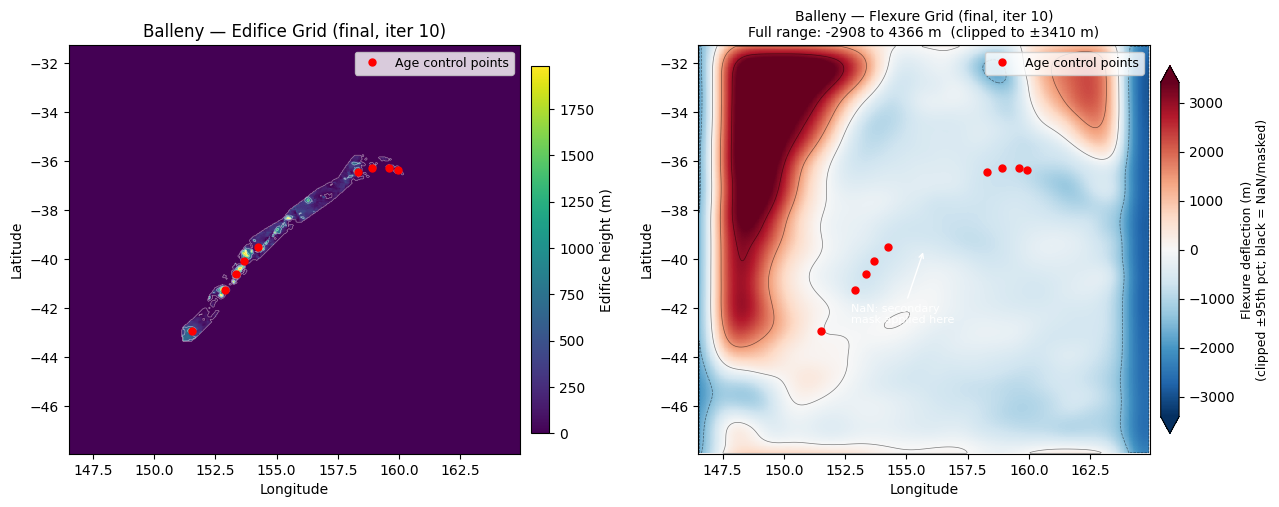

Clipped flexure colorbar to : ±3410 m
NOTE: Black region = NaN from secondary masking in Step 12.
NOTE: Values beyond ±3410 m (shown as solid red/blue) include the peripheral flexural bulge at grid edges.


In [41]:
# ── Plot final edifice and flexure grids side by side (after Step 12) ────────
# Same colorbar and style as the plot after Step 7

%matplotlib inline
# Use ii_final saved at end of Step 11 — guaranteed to be the correct iteration
_flex_final = f'flexure.DENAN.{ii_final}.grd'
ii_plot = ii_final
print(f'Using flexure file: {_flex_final}  (ii_plot = {ii_plot})')

Xe,  Ye,  Ze  = grdread2(f'{grdfile}_edifice.grd')
Xfl, Yfl, Zfl = grdread2(_flex_final)

print('Shape of edifice.grd:', Xe.shape, Ye.shape, Ze.shape)
print('Shape of flexure.grd:', Xfl.shape, Yfl.shape, Zfl.shape)
print(f'Edifice height range  : {np.nanmin(Ze[Ze>0]):.0f} – {np.nanmax(Ze):.0f} m')
print(f'Flexure full range    : {np.nanmin(Zfl):.0f} – {np.nanmax(Zfl):.0f} m')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Edifice ───────────────────────────────────────────────────────────────────
ax = axes[0]
vmax_e = np.nanpercentile(Ze[Ze > 0], 98)
im0 = ax.pcolormesh(Xe, Ye, Ze, cmap='viridis', vmin=0, vmax=vmax_e, shading='auto')
cb0 = fig.colorbar(im0, ax=ax, pad=0.02, shrink=0.85)
cb0.set_label('Edifice height (m)', fontsize=10)
ax.contour(Xe, Ye, Ze, levels=6, colors='white', linewidths=0.5, alpha=0.5)
ax.plot(AGES[:, 0], AGES[:, 1], 'ro', markersize=5, label='Age control points')
ax.set_title(f'{grdname} — Edifice Grid (final, iter {ii_plot})', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')

# ── Flexure ───────────────────────────────────────────────────────────────────
# Clip colorbar to ±5th–95th percentile of values NEAR the edifice only,
# so edge artefacts / peripheral bulge don't dominate the colour scale.
# NaN values (from secondary masking) shown in black.
ax = axes[1]
_Zfl_valid = Zfl[~np.isnan(Zfl)]
vmax_f = np.nanpercentile(np.abs(_Zfl_valid), 95)   # clip at 95th percentile
cmap_f = plt.cm.RdBu_r.copy()
cmap_f.set_bad(color='black')                        # NaN → black, clearly labelled

im1 = ax.pcolormesh(Xfl, Yfl, Zfl, cmap=cmap_f,
                    vmin=-vmax_f, vmax=vmax_f, shading='auto')
cb1 = fig.colorbar(im1, ax=ax, pad=0.02, shrink=0.85, extend='both')
cb1.set_label('Flexure deflection (m)\n(clipped ±95th pct; black = NaN/masked)', fontsize=9)
ax.contour(Xfl, Yfl, Zfl, levels=6, colors='k', linewidths=0.5, alpha=0.5)
ax.plot(AGES[:, 0], AGES[:, 1], 'ro', markersize=5, label='Age control points')
ax.set_title(f'{grdname} — Flexure Grid (final, iter {ii_plot})\n'
             f'Full range: {np.nanmin(Zfl):.0f} to {np.nanmax(Zfl):.0f} m  '
             f'(clipped to ±{vmax_f:.0f} m)', fontsize=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')

# Annotate the black (NaN) region
ax.annotate('NaN: secondary\nmask applied here',
            xy=(np.mean(Xe), np.mean(Ye)),
            xytext=(np.mean(Xe) - 3, np.mean(Ye) - 3),
            color='white', fontsize=8,
            arrowprops=dict(arrowstyle='->', color='white', lw=1.0))

plt.tight_layout()
plt.savefig(f'results/{grdname}_edifice_flexure_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Clipped flexure colorbar to : ±{vmax_f:.0f} m')
print(f'NOTE: Black region = NaN from secondary masking in Step 12.')
print(f'NOTE: Values beyond ±{vmax_f:.0f} m (shown as solid red/blue) '
      f'include the peripheral flexural bulge at grid edges.')


## Steps 13 & 14 — Cross-section Sampling and Volume Calculation

### What is `{grdfile}Xes.txt`?
GMT `grdtrack -C1000k/4k/4k -Ar` cuts **perpendicular cross-sections** along the hotspot track,
spaced every **4 km**, each **1000 km wide** (±500 km either side of the track centreline).
Each profile samples 4 grids at every 4 km along the cross-section:
- Col 4: `edifice.grd` — edifice height above the regional seafloor (m)
- Col 5: `flexure.DENAN.grd` — lithospheric flexure depression (m, negative = downward)
- Col 6: `Uplate.grd` — underplating thickness (km, full grid, unmasked)
- Col 7: `Uplate.INP.grd` — underplating thickness (km, **INP-masked**, inside edifice polygon only)

NaN rows in the file separate individual profiles.

---

### How volumes are calculated — three components

Each cross-section profile gives a 2-D slice (distance along profile vs. height).
Volume is estimated by **integrating each profile** along its perpendicular axis (trapz),
then summing contributions along the track.

#### 1. Edifice volume (`VolEd`)
```
VolEd = trapz(distance, edifice_height / 1000)   [km²·km = km³ per km of track]
```
Straightforward trapezoidal integration of the edifice cross-section above the regional seafloor.
No smoothing applied — raw profile is used directly.

#### 2. Infill volume (`VolFill`) — flexural moat
```
FLX = -flexure   (flip sign: flexure is negative downward, infill is positive)
FLX = detrend(FLX)   (remove linear background tilt)
FLX = FLX - min(FLX)   (shift baseline to zero)
VolFill = trapz(distance, FLX / 1000)
```
The **flexural moat** is the depression around the seamount caused by the weight of the edifice.
Sediments and volcanic material fill this moat — this is the **infill volume**.
A linear trend is removed first to correct for any regional seafloor slope.

#### 3. Underplating volume (`VolUpl`) — Gaussian fit + 68.3% rule
```
UPL = detrend(underplating_profile)
UPL = UPL - min(UPL)
Fit a Gaussian window to UPL (best-fit sigma by minimising RMS)
GUSUPL = gaussian(N, best_sigma) × max(UPL)
VolUpl = 0.683 × trapz(distance, GUSUPL)
```
Underplating is **smoothed by fitting a Gaussian window** because the Parker-Oldenburg inversion
produces a noisy profile. The Gaussian is scaled to the peak value.
The **0.683 factor** = area under ±1σ of a Gaussian = 68.3% — this retains only the
central "core" of the Gaussian, excluding the long tails which are considered noise.

---

### Output `VOL` table — columns
| Col | Content |
|-----|---------|
| 0 | Longitude of cross-section centre (track point) |
| 1 | Latitude of cross-section centre |
| 2 | VolEd (km³ per km of track) |
| 3 | VolFill (km³ per km of track) |
| 4 | VolUpl (km³ per km of track) |
| 5 | Cumulative along-track distance (km) |
| 6 | Age (Ma) — filled by `IHotVol_AgeVolPlot` |

`IHotVol_AgeVolPlot` assigns ages to each cross-section by interpolating from `HSPT_TRK`,
then plots volume vs. age and distance along the hotspot track.

In [43]:
%matplotlib inline

Xes = load_gmt_table(f'{grdfile}Xes.txt')
VOL, Crosses = IHotVol_VolumeSlices(Xes, HSPT_TRK)
VOL = IHotVol_AgeVolPlot(VOL, Crosses, pA)
print('Volumes calculated. Figures saved to results/.')

Saved results/volume_components.png
Volumes calculated. Figures saved to results/.


### Volume cross-section diagnostics
Plot 4 example cross-sections spaced along the track, showing each volume component with filled areas and the Gaussian fit for underplating.

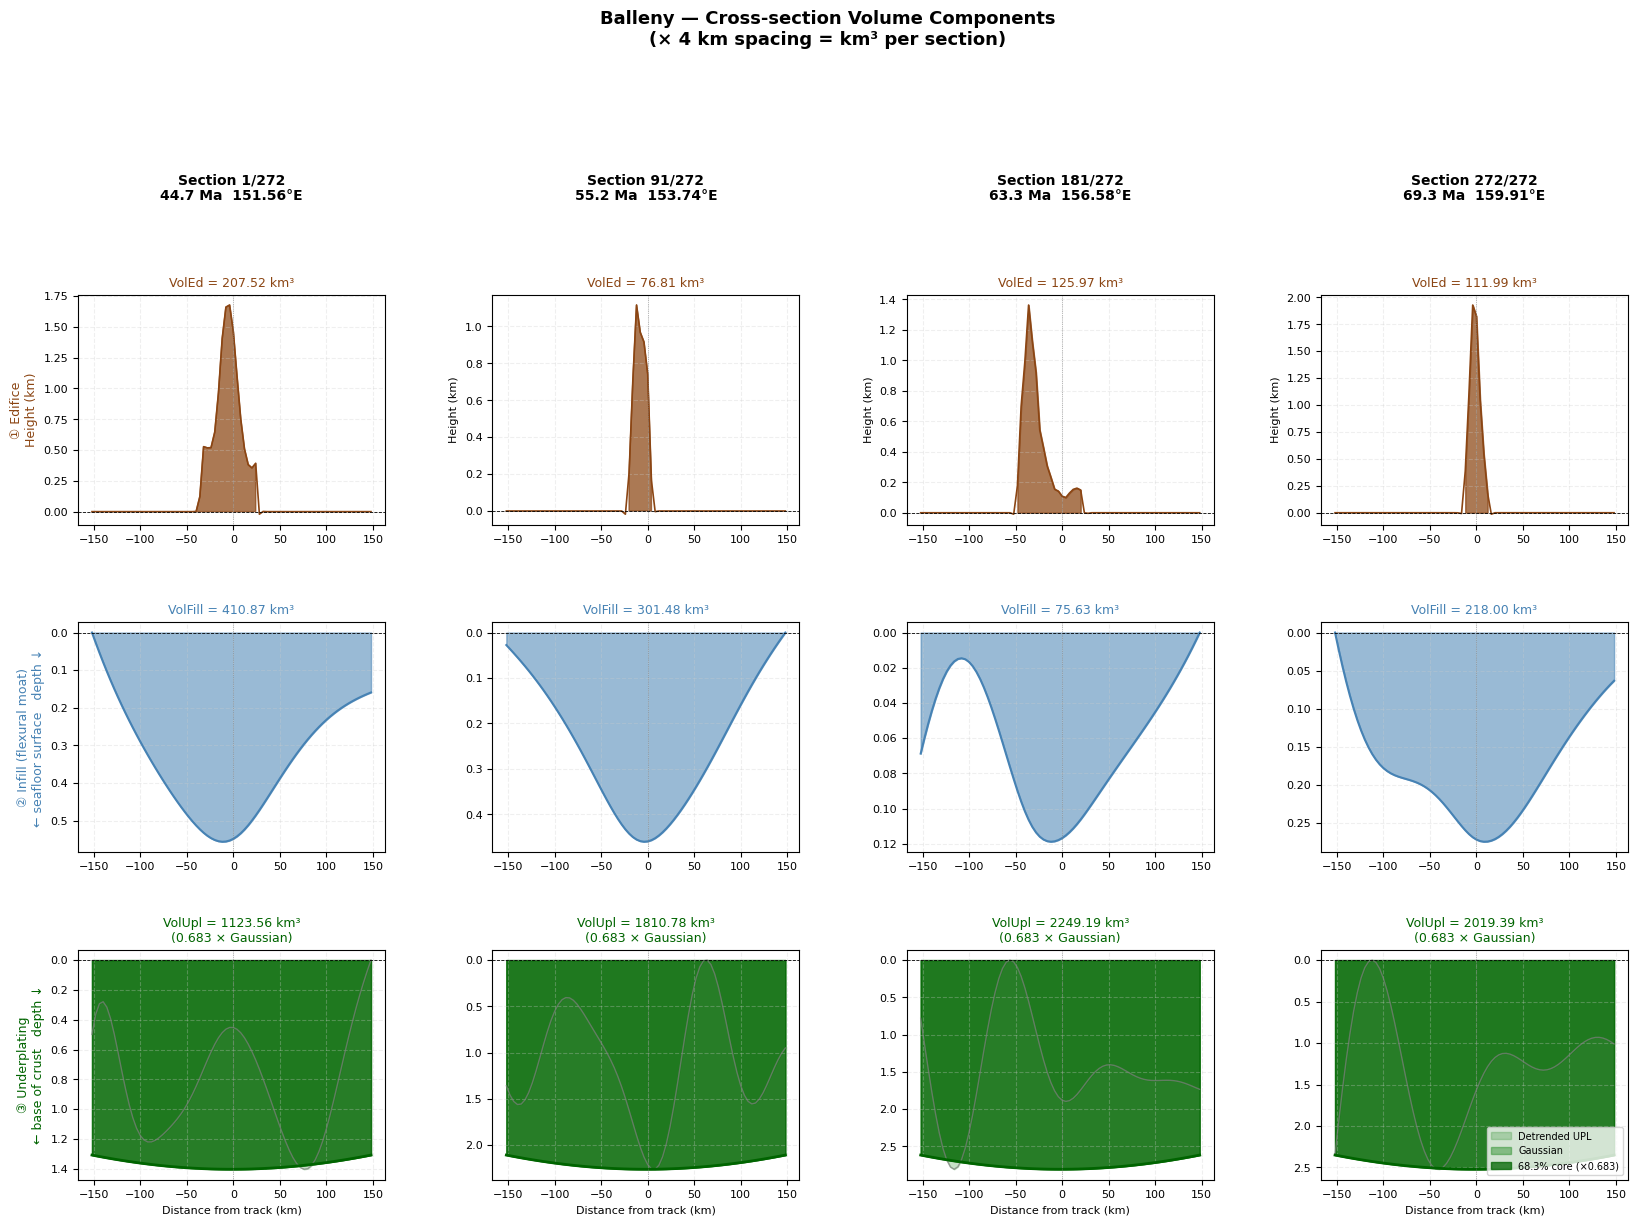

Saved results/Balleny_cross_section_diagnostics.png


In [44]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import windows as sig_windows
from IHotVol_VolumeSlices import _fit_gausswin
import matplotlib
BG   = 'white'      # figure/axes background
FG   = 'black'     # text, ticks, spines
GRID = '#cccccc'   # gridlines

# ── Select 4 evenly-spaced cross-sections as examples ────────────────────────
n_show = 4
n_total = len(Crosses)
ex_idx = np.linspace(0, n_total - 1, n_show, dtype=int)

fig = plt.figure(figsize=(5 * n_show, 13), facecolor=BG)
# 4 columns × 4 rows: row0=map-stripe, row1=edifice, row2=infill, row3=underplating
gs = gridspec.GridSpec(4, n_show, figure=fig,
                       height_ratios=[0.08, 1, 1, 1], hspace=0.55, wspace=0.35)

row_colors  = ['saddlebrown', 'steelblue', 'forestgreen']
row_labels  = ['① Edifice', '② Infill (flexural moat)', '③ Underplating']
vol_cols    = [2, 3, 4]

for col, cs_i in enumerate(ex_idx):
    PRFL = Crosses[cs_i].copy()
    PRFL[np.isnan(PRFL)] = 0.0
    dist = PRFL[:, 2]          # cross-section distance (km), 0 = track centre
    age_lbl = f'{VOL[cs_i, 6]:.1f} Ma'
    lon_lbl = f'{VOL[cs_i, 0]:.2f}°E'

    # ── Column header ─────────────────────────────────────────────────────────
    ax_hdr = fig.add_subplot(gs[0, col])
    ax_hdr.axis('off')
    ax_hdr.text(0.5, 0.5,
                f'Section {cs_i+1}/{n_total}\n{age_lbl}  {lon_lbl}',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color=FG, transform=ax_hdr.transAxes)

    # ── ① Edifice ─────────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, col])
    edifice = PRFL[:, 4] / 1e3          # m → km
    ax.fill_between(dist, 0, edifice,
                    where=edifice > 0,
                    color='saddlebrown', alpha=0.65, label='Edifice')
    ax.plot(dist, edifice, color='saddlebrown', linewidth=1.2)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle=':')
    # shade integration region
    ax.fill_between(dist, 0, edifice,
                    where=edifice > 0,
                    color='saddlebrown', alpha=0.2)
    vol_val = VOL[cs_i, 2] * 4
    ax.set_title(f'VolEd = {vol_val:.2f} km³', fontsize=9, color='saddlebrown')
    ax.set_ylabel('Height (km)', fontsize=8)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.3, linestyle='--', color=GRID)
    ax.tick_params(labelsize=8, colors=FG)
    if col == 0:
        ax.set_ylabel('① Edifice\nHeight (km)', fontsize=9, color='saddlebrown')

    # ── ② Infill (flexure) ────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[2, col])
    FLX = -PRFL[:, 5].copy()            # flip sign: flexure is –ve downward
    p   = np.polyfit(dist, FLX, 1)
    FLX -= np.polyval(p, dist)           # detrend: remove regional seafloor slope
    FLX -= FLX.min()                     # shift baseline to zero
    # Clip to positive (moat is above zero after baseline shift)
    FLX_plot = np.where(FLX > 0, FLX, 0.0)

    ax.fill_between(dist, 0, FLX_plot / 1e3,
                    color='steelblue', alpha=0.55)
    ax.plot(dist, FLX_plot / 1e3, color='steelblue', linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle=':')
    ax.invert_yaxis()   # moat goes DOWN like reality (depression below seafloor)
    vol_val = VOL[cs_i, 3] * 4
    ax.set_title(f'VolFill = {vol_val:.2f} km³', fontsize=9, color='steelblue')
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.3, linestyle='--', color=GRID)
    ax.tick_params(labelsize=8, colors=FG)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(FG)
    if col == 0:
        ax.set_ylabel('② Infill (flexural moat)\n← seafloor surface   depth ↓', fontsize=9, color='steelblue')

    # ── ③ Underplating ────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[3, col])
    UPL     = PRFL[:, 6].copy()
    UPL_INP = PRFL[:, 7].copy()
    p = np.polyfit(dist, UPL, 1)
    UPL -= np.polyval(p, dist)           # detrend
    UPL -= UPL.min()                     # zero baseline
    PEAK_upl   = UPL_INP.max() if UPL_INP.max() > 0 else UPL.max()
    best_tw_u  = _fit_gausswin(UPL, PEAK_upl)
    GUSUPL     = sig_windows.gaussian(len(UPL), best_tw_u) * UPL.max()

    # Mark the ±1σ core (where Gaussian ≥ e^{-0.5} × peak → the 68.3% region)
    core_mask = GUSUPL >= GUSUPL.max() * np.exp(-0.5)

    ax.fill_between(dist, 0, UPL,
                    color='forestgreen', alpha=0.25, label='Detrended UPL')
    ax.fill_between(dist, 0, GUSUPL,
                    color='forestgreen', alpha=0.45, label='Gaussian')
    ax.fill_between(dist, 0, GUSUPL, where=core_mask,
                    color='darkgreen', alpha=0.75, label='68.3% core (×0.683)')
    ax.plot(dist, UPL,    color='grey',      linewidth=1.0, alpha=0.7)
    ax.plot(dist, GUSUPL, color='darkgreen', linewidth=2.0)
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle=':')
    ax.invert_yaxis()   # underplating grows DOWNWARD (below the crust)
    vol_val = VOL[cs_i, 4] * 4
    ax.set_title(f'VolUpl = {vol_val:.2f} km³\n(0.683 × Gaussian)', fontsize=9, color='darkgreen')
    ax.set_xlabel('Distance from track (km)', fontsize=8)
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.3, linestyle='--', color=GRID)
    ax.tick_params(labelsize=8, colors=FG)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(FG)
    if col == 0:
        ax.set_ylabel('③ Underplating\n← base of crust   depth ↓', fontsize=9, color='darkgreen')
    if col == n_show - 1:
        ax.legend(fontsize=7, loc='lower right')

fig.suptitle(f'{grdname} — Cross-section Volume Components\n'
             f'(× 4 km spacing = km³ per section)',
             fontsize=13, fontweight='bold', y=1.01, color=FG)

outpath = f'results/{grdname}_cross_section_diagnostics.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved {outpath}')


### Bathymetry cross-sections: regional vs full topography, and residual vs edifice

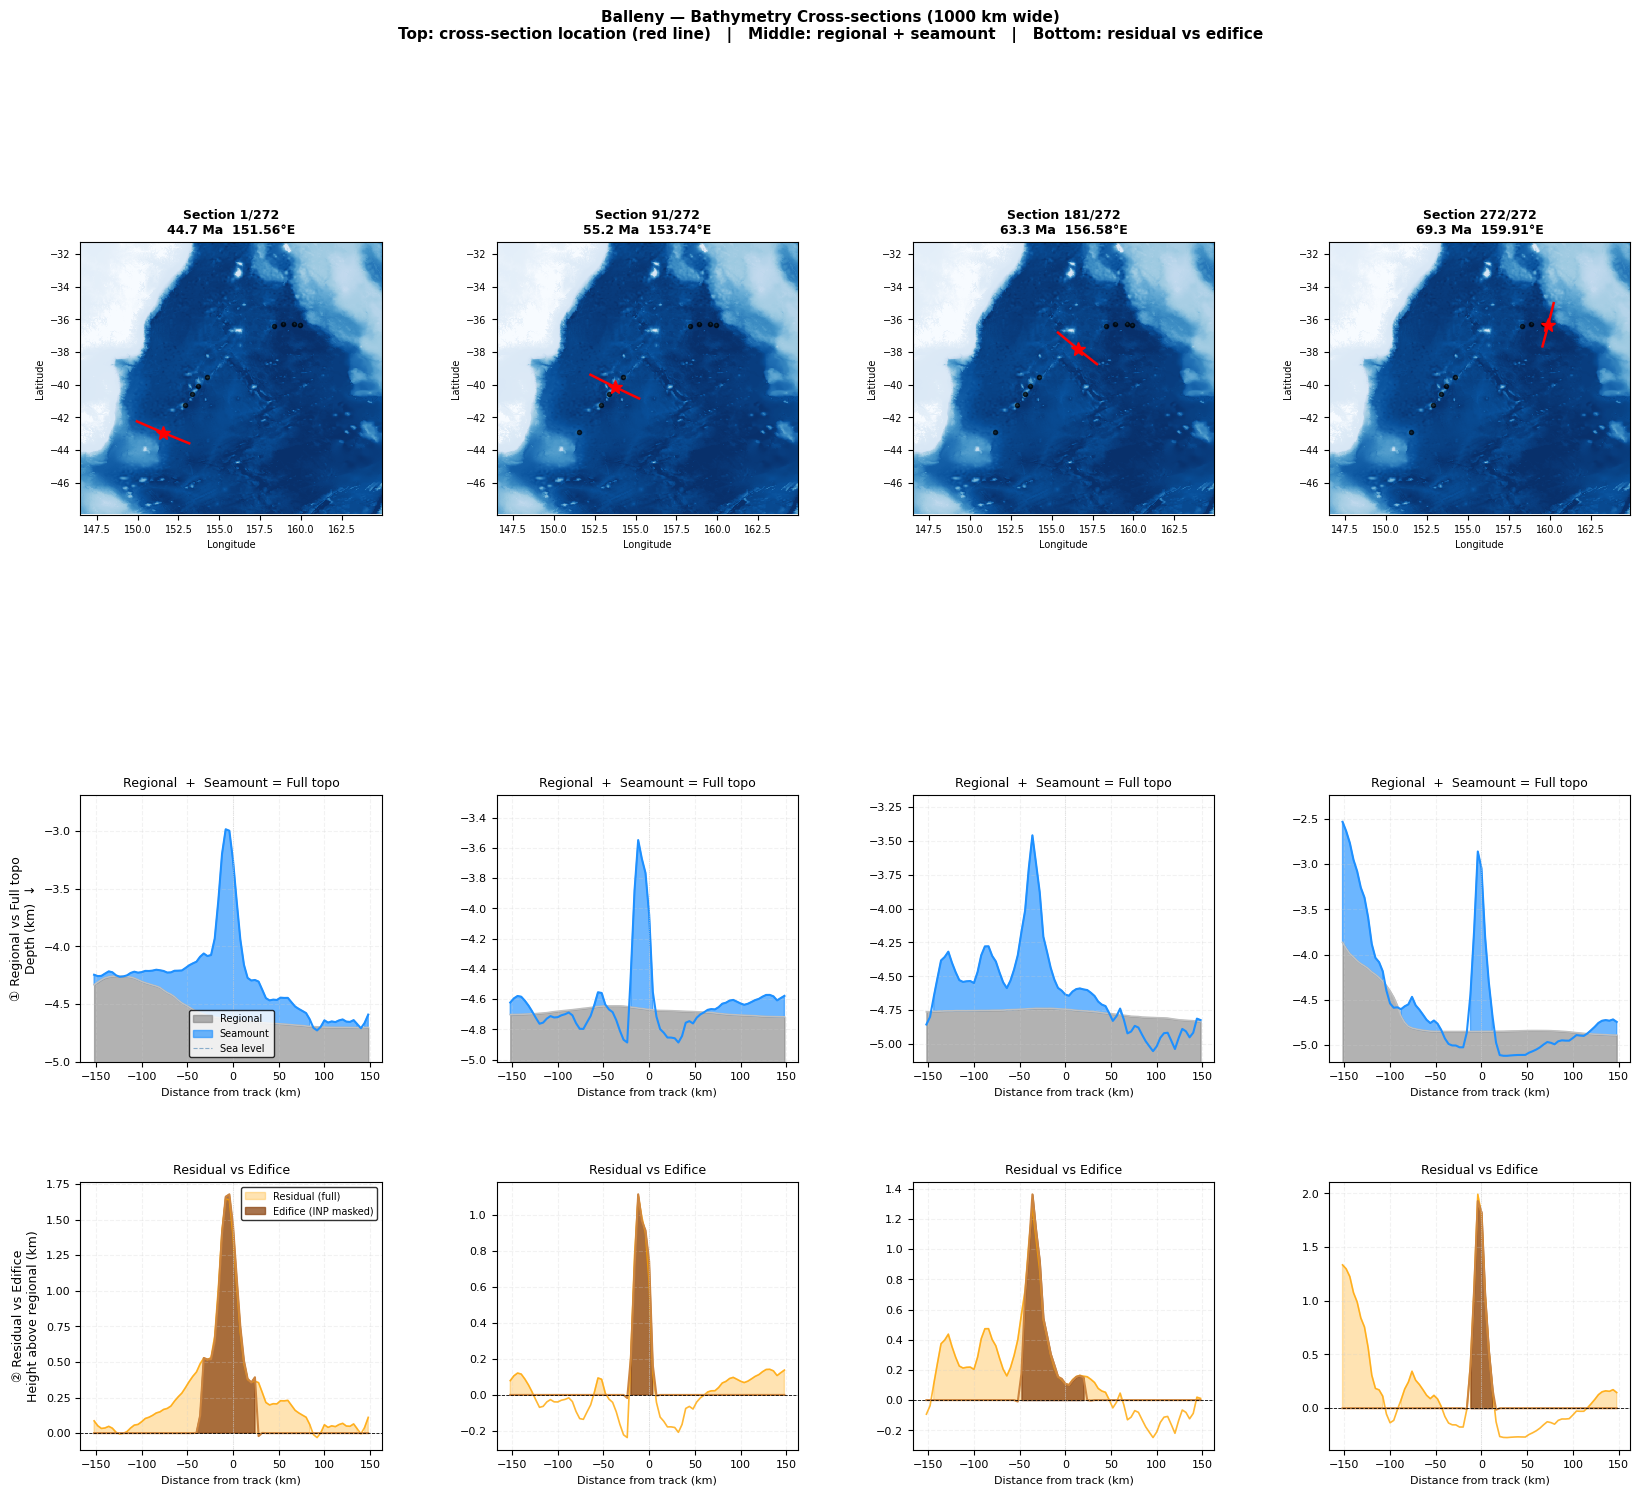

Saved results/Balleny_bathy_cross_sections.png


In [45]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import RegularGridInterpolator
BG   = 'white'   
FG   = 'black'
GRID = '#cccccc'

# ── Load grids ────────────────────────────────────────────────────────────────
X_reg, Y_reg, Z_reg = grdread2(f'{grdfile}_regional.grd')
X_res, Y_res, Z_res = grdread2(f'{grdfile}_residual.grd')
X_full, Y_full, Z_full = grdread2(grdfile)   # full bathymetry for map row

interp_reg = RegularGridInterpolator(
    (Y_reg, X_reg), Z_reg, method='linear', bounds_error=False, fill_value=np.nan)
interp_res = RegularGridInterpolator(
    (Y_res, X_res), Z_res, method='linear', bounds_error=False, fill_value=np.nan)

# ── Same 4 cross-sections as the previous plot ───────────────────────────────
n_show  = 4
n_total = len(Crosses)
ex_idx  = np.linspace(0, n_total - 1, n_show, dtype=int)

# Colorscale for map row — same as full bathymetry (Blues_r like cell 12)
_vmin_full = np.nanpercentile(Z_full, 2)
_vmax_full = np.nanpercentile(Z_full, 98)

fig = plt.figure(figsize=(5 * n_show, 16), facecolor=BG)
# 4 rows: map location, header, regional vs full, residual vs edifice
gs = gridspec.GridSpec(4, n_show, figure=fig,
                       height_ratios=[1.2, 0.06, 1, 1], hspace=0.55, wspace=0.38)

for col, cs_i in enumerate(ex_idx):
    PRFL    = Crosses[cs_i].copy()
    PRFL[np.isnan(PRFL)] = 0.0
    dist    = PRFL[:, 2]
    lon_pts = PRFL[:, 0]
    lat_pts = PRFL[:, 1]
    age_lbl = f'{VOL[cs_i, 6]:.1f} Ma'
    lon_lbl = f'{VOL[cs_i, 0]:.2f}°E'

    pts         = np.column_stack([lat_pts, lon_pts])
    reg_prof    = interp_reg(pts)
    res_prof    = interp_res(pts)
    full_prof   = reg_prof + res_prof
    edifice_m   = PRFL[:, 4]

    # ── Row 0: Map showing cross-section location ─────────────────────────────
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(BG)

    # Full bathymetry — same style as Step 4 (Blues_r)
    ax.pcolormesh(X_full, Y_full, Z_full,
                  cmap='Blues_r', vmin=_vmin_full, vmax=_vmax_full,
                  shading='auto', rasterized=True)

    # Cross-section as a red line
    ax.plot(lon_pts, lat_pts, color='red', linewidth=1.8, zorder=5)

    # Mark the track centre (distance=0)
    _ctr = np.where(np.abs(dist) == np.abs(dist).min())[0]
    if len(_ctr):
        ax.plot(lon_pts[_ctr[0]], lat_pts[_ctr[0]],
                'r*', markersize=10, zorder=6, label='Track centre')

    # Hotspot track dots
    ax.plot(AGES[:, 0], AGES[:, 1], 'ko', markersize=3, alpha=0.7, zorder=4)

    ax.set_title(f'Section {cs_i+1}/{n_total}\n{age_lbl}  {lon_lbl}',
                 fontsize=9, fontweight='bold', color=FG)
    ax.set_xlabel('Longitude', fontsize=7, color=FG)
    ax.set_ylabel('Latitude',  fontsize=7, color=FG)
    ax.tick_params(labelsize=7, colors=FG)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(FG)
    ax.set_aspect('equal')

    # ── Row 1: thin header (hidden — info already in map title) ───────────────
    ax_hdr = fig.add_subplot(gs[1, col])
    ax_hdr.axis('off')

    # ── Row 2: Regional (grey) vs Full topography (blue) ─────────────────────
    ax = fig.add_subplot(gs[2, col])
    ax.set_facecolor(BG)
    depth_floor = np.nanmin(reg_prof) / 1e3 - 0.3
    ax.fill_between(dist, reg_prof / 1e3, depth_floor,
                    color='grey', alpha=0.6, label='Regional')
    ax.plot(dist, reg_prof / 1e3, color='silver', linewidth=1.2)
    ax.fill_between(dist, reg_prof / 1e3, full_prof / 1e3,
                    where=full_prof > reg_prof,
                    color='dodgerblue', alpha=0.65, label='Seamount')
    ax.plot(dist, full_prof / 1e3, color='dodgerblue', linewidth=1.5)
    ax.axhline(0, color='steelblue', linewidth=0.8, linestyle='--', alpha=0.6, label='Sea level')
    ax.axvline(0, color=GRID, linewidth=0.5, linestyle=':')
    ax.invert_yaxis()
    ax.set_ylim(top=np.nanmax(full_prof) / 1e3 + 0.3, bottom=depth_floor)
    ax.set_title('Regional  +  Seamount = Full topo', fontsize=9, color=FG)
    ax.grid(True, alpha=0.25, linestyle='--', color=GRID)
    ax.tick_params(labelsize=8, colors=FG)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(FG)
    ax.set_xlabel('Distance from track (km)', fontsize=8, color=FG)
    if col == 0:
        ax.set_ylabel('① Regional vs Full topo\nDepth (km)  ↓', fontsize=9, color=FG)
        ax.legend(fontsize=7, loc='lower center',
                  facecolor='white', edgecolor=FG, labelcolor=FG)

    # ── Row 3: Residual (orange) vs Edifice (brown) ───────────────────────────
    ax = fig.add_subplot(gs[3, col])
    ax.set_facecolor(BG)
    valid_res = np.where(np.isfinite(res_prof), res_prof, 0.0)
    ax.fill_between(dist, 0, valid_res / 1e3,
                    where=valid_res > 0,
                    color='orange', alpha=0.30, label='Residual (full)')
    ax.plot(dist, valid_res / 1e3, color='orange', linewidth=1.2, alpha=0.8)
    ax.fill_between(dist, 0, edifice_m / 1e3,
                    where=edifice_m > 0,
                    color='saddlebrown', alpha=0.75, label='Edifice (INP masked)')
    ax.plot(dist, edifice_m / 1e3, color='peru', linewidth=1.5)
    ax.axhline(0, color=FG, linewidth=0.6, linestyle='--')
    ax.axvline(0, color=GRID, linewidth=0.5, linestyle=':')
    ax.set_title('Residual vs Edifice', fontsize=9, color=FG)
    ax.grid(True, alpha=0.25, linestyle='--', color=GRID)
    ax.tick_params(labelsize=8, colors=FG)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(FG)
    ax.set_xlabel('Distance from track (km)', fontsize=8, color=FG)
    if col == 0:
        ax.set_ylabel('② Residual vs Edifice\nHeight above regional (km)', fontsize=9, color=FG)
        ax.legend(fontsize=7, loc='upper right',
                  facecolor='white', edgecolor=FG, labelcolor=FG)

fig.suptitle(
    f'{grdname} — Bathymetry Cross-sections (1000 km wide)\n'
    f'Top: cross-section location (red line)   |   '
    f'Middle: regional + seamount   |   Bottom: residual vs edifice',
    fontsize=11, fontweight='bold', color=FG, y=1.01)

outpath = f'results/{grdname}_bathy_cross_sections.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved {outpath}')


Subset window: lon [148.96, 161.25]  lat [-44.58, -34.01]
GEBCO subset: 2536 lat × 2948 lon  (-44.58–-34.01°N, 148.96–161.24°E)
GEBCO elevation range: -5993 – 1598 m


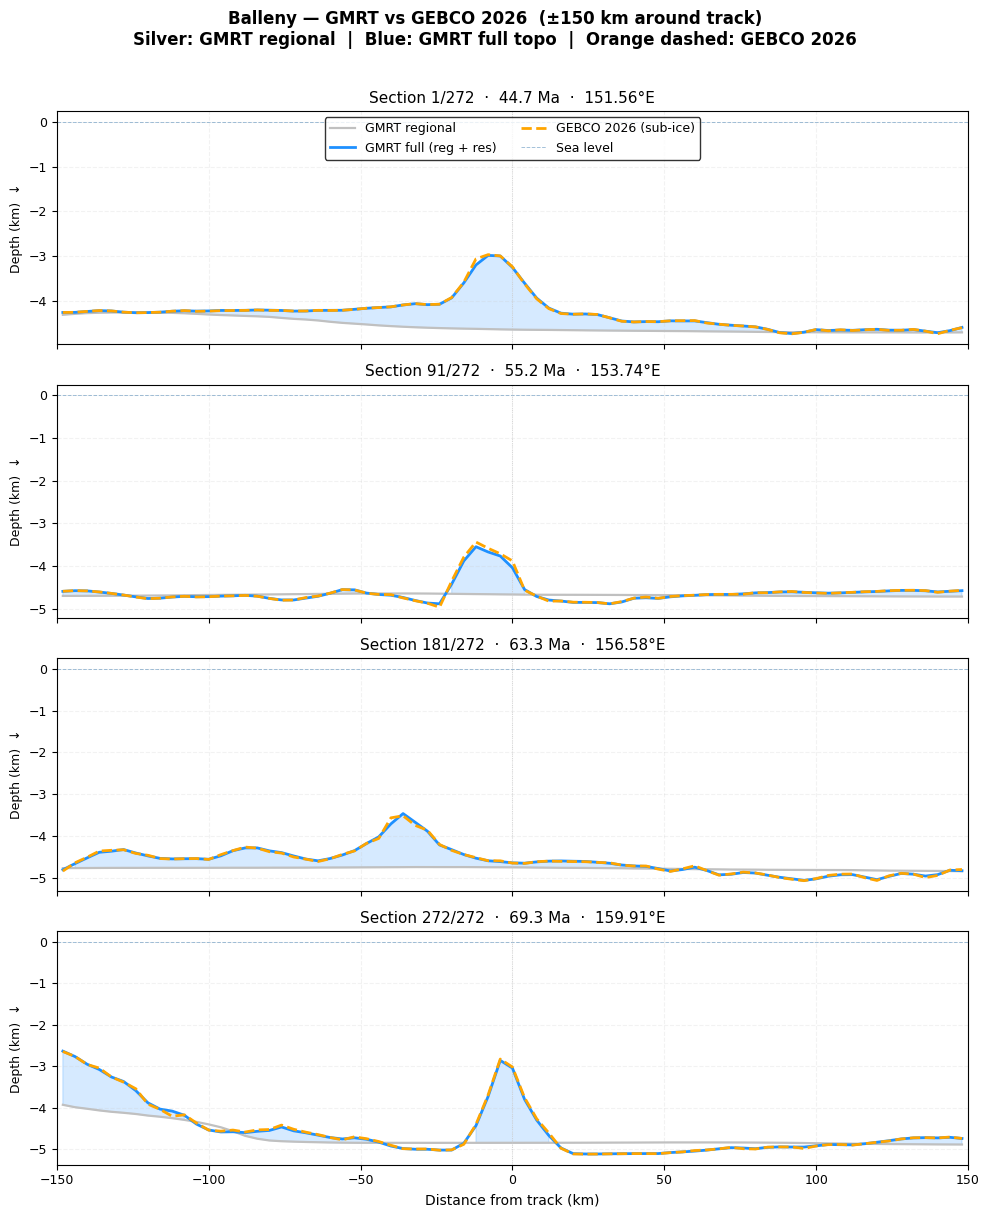

Saved results/Balleny_GMRT_vs_GEBCO.png


In [50]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from scipy.interpolate import RegularGridInterpolator
BG   = 'white'   
FG   = 'black'
GRID = '#cccccc'

GEBCO_PATH = '../2024_Archean_paper3/find_examples/bathymetry/GEBCO_2026_sub_ice.nc'
DIST_CLIP  = 150   # km — show full ±150 km (matches 300 km cross-section width)

# ── Same 4 cross-sections as previous plots ───────────────────────────────────
n_show  = 4
n_total = len(Crosses)
ex_idx  = np.linspace(0, n_total - 1, n_show, dtype=int)

# ── Compute bounding box from cross-section lon/lat ───────────────────────────
all_lons = np.concatenate([Crosses[cs_i][:, 0] for cs_i in ex_idx])
all_lats = np.concatenate([Crosses[cs_i][:, 1] for cs_i in ex_idx])
all_lons = all_lons[np.isfinite(all_lons)]
all_lats = all_lats[np.isfinite(all_lats)]

lon_min = float(all_lons.min()) - 1.0
lon_max = float(all_lons.max()) + 1.0
lat_min = float(all_lats.min()) - 1.0
lat_max = float(all_lats.max()) + 1.0
print(f'Subset window: lon [{lon_min:.2f}, {lon_max:.2f}]  lat [{lat_min:.2f}, {lat_max:.2f}]')

# ── Load GEBCO subset (avoids loading 7 GB of global grid) ────────────────────
with nc.Dataset(GEBCO_PATH, 'r') as ds:
    lon_g_full = np.array(ds.variables['lon'][:])
    lat_g_full = np.array(ds.variables['lat'][:])

    lon_idx = np.where((lon_g_full >= lon_min) & (lon_g_full <= lon_max))[0]
    lat_idx = np.where((lat_g_full >= lat_min) & (lat_g_full <= lat_max))[0]

    if len(lon_idx) == 0 or len(lat_idx) == 0:
        raise ValueError(
            f'GEBCO subset is empty for lon [{lon_min},{lon_max}] '
            f'lat [{lat_min},{lat_max}].  Check longitude convention.')

    lon_g = lon_g_full[lon_idx]
    lat_g = lat_g_full[lat_idx]
    z_g = np.array(
        ds.variables['elevation'][
            lat_idx[0]:lat_idx[-1] + 1,
            lon_idx[0]:lon_idx[-1] + 1],
        dtype=np.float32)

print(f'GEBCO subset: {z_g.shape[0]} lat × {z_g.shape[1]} lon  '
      f'({lat_g.min():.2f}–{lat_g.max():.2f}°N, '
      f'{lon_g.min():.2f}–{lon_g.max():.2f}°E)')
print(f'GEBCO elevation range: {np.nanmin(z_g):.0f} – {np.nanmax(z_g):.0f} m')

# ── Interpolators ─────────────────────────────────────────────────────────────
interp_gebco = RegularGridInterpolator(
    (lat_g, lon_g), z_g, method='linear', bounds_error=False, fill_value=np.nan)

_X_reg, _Y_reg, _Z_reg = grdread2(f'{grdfile}_regional.grd')
_X_res, _Y_res, _Z_res = grdread2(f'{grdfile}_residual.grd')
_interp_reg = RegularGridInterpolator(
    (_Y_reg, _X_reg), _Z_reg, method='linear', bounds_error=False, fill_value=np.nan)
_interp_res = RegularGridInterpolator(
    (_Y_res, _X_res), _Z_res, method='linear', bounds_error=False, fill_value=np.nan)

# ── Plot: 4 rows × 1 column ───────────────────────────────────────────────────
fig, axes = plt.subplots(n_show, 1, figsize=(10, 3 * n_show), facecolor=BG, sharex=True)
if n_show == 1:
    axes = [axes]

for row, cs_i in enumerate(ex_idx):
    PRFL = Crosses[cs_i].copy()
    PRFL[np.isnan(PRFL)] = 0.0
    dist    = PRFL[:, 2]
    lon_pts = PRFL[:, 0]
    lat_pts = PRFL[:, 1]

    # Clip to ±DIST_CLIP km
    clip_mask = np.abs(dist) <= DIST_CLIP
    dist_c    = dist[clip_mask]
    pts_c     = np.column_stack([lat_pts[clip_mask], lon_pts[clip_mask]])

    # Profiles (m)
    reg_prof   = _interp_reg(pts_c)
    res_prof   = _interp_res(pts_c)
    full_prof  = reg_prof + res_prof
    gebco_prof = interp_gebco(pts_c)

    age_lbl = f'{VOL[cs_i, 6]:.1f} Ma'
    lon_lbl = f'{VOL[cs_i, 0]:.2f}°E'

    ax = axes[row]
    ax.set_facecolor(BG)

    # 1. GMRT regional (grey — broad seafloor background)
    ax.plot(dist_c, reg_prof  / 1e3, color='silver',     linewidth=1.6,
            linestyle='-',  label='GMRT regional',        zorder=2)

    # 2. GMRT full topo = regional + residual (blue — includes the seamount)
    ax.plot(dist_c, full_prof / 1e3, color='dodgerblue', linewidth=2.0,
            linestyle='-',  label='GMRT full (reg + res)', zorder=3)

    # 3. GEBCO 2026 sub-ice (orange dashed — independent comparison dataset)
    ax.plot(dist_c, gebco_prof / 1e3, color='orange',    linewidth=2.0,
            linestyle='--', label='GEBCO 2026 (sub-ice)', zorder=4)

    # Fill between regional and full to highlight the seamount body
    ax.fill_between(dist_c, reg_prof / 1e3, full_prof / 1e3,
                    where=full_prof > reg_prof,
                    color='dodgerblue', alpha=0.18, zorder=1)

    ax.axhline(0, color='steelblue', linewidth=0.7, linestyle='--', alpha=0.5,
               label='Sea level')
    ax.axvline(0, color=GRID,  linewidth=0.6, linestyle=':')

    ax.invert_yaxis()
    ax.set_xlim(-DIST_CLIP, DIST_CLIP)

    ax.set_title(
        f'Section {cs_i + 1}/{n_total}  ·  {age_lbl}  ·  {lon_lbl}',
        fontsize=11, color=FG)
    ax.set_ylabel('Depth (km)  ↓', fontsize=9, color=FG)
    ax.grid(True, alpha=0.25, linestyle='--', color=GRID)
    ax.tick_params(labelsize=9, colors=FG)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(FG)
    for sp in ax.spines.values():
        sp.set_edgecolor(FG)

    if row == n_show - 1:
        ax.set_xlabel('Distance from track (km)', fontsize=10, color=FG)
    if row == 0:
        ax.legend(fontsize=9, loc='upper center',
                  facecolor='white', edgecolor=FG, labelcolor=FG, ncol=2)

fig.suptitle(
    f'{grdname} — GMRT vs GEBCO 2026  (±{DIST_CLIP} km around track)\n'
    f'Silver: GMRT regional  |  Blue: GMRT full topo  |  Orange dashed: GEBCO 2026',
    fontsize=12, fontweight='bold', color=FG, y=1.01)

for ax in axes.flat:
    ax.invert_yaxis()

plt.tight_layout()
outpath = f'results/{grdname}_GMRT_vs_GEBCO.png'
plt.savefig(outpath, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved {outpath}')


## Edifice Volume per Seamount (AGES locations)

Each entry in `AGES.txt` represents a distinct seamount along the hotspot track.

**Method — Voronoi partition:**
Every cross-section (spaced 4 km along the track) is assigned to its nearest AGES point using great-circle distance (3-D unit-sphere KDTree). The sections assigned to each seamount then span its natural along-track extent without any arbitrary fixed window.

> **Volume = Σᵢ VolEdᵢ × 4 km** &emsp; (cross-section area km² × profile spacing km = km³)

All four volume components (edifice, infill, underplating, total) are saved to Excel.

In [77]:
import pandas as pd
from scipy.spatial import cKDTree

PROFILE_SPACING_KM = 4   # km between consecutive cross-sections along track

# ── Manual n_sec per seamount (1-based row index = order in AGES.txt) ─────────
# Set how many cross-sections to use for each seamount.
# Sections are chosen symmetrically around the closest track point to the AGES
# location — so cap=10 means 5 slices either side of the seamount centre.
# If not listed, defaults to N_MAX.
N_MAX = 30
N_SEC_OVERRIDE = {
     1: 3,   # lon=151.530, lat=-42.910, age=43.3 Ma
     2: 12,   # lon=152.890, lat=-41.240, age=53.6 Ma
     3: 35,   # lon=153.350, lat=-40.580, age=53.9 Ma
     4: 16,   # lon=153.680, lat=-40.080, age=55.2 Ma
     5: 6,   # lon=154.240, lat=-39.510, age=56.1 Ma
     6: 9,   # lon=158.310, lat=-36.420, age=64.2 Ma
     7: 12,   # lon=158.890, lat=-36.280, age=69.0 Ma
     8: 4,   # lon=159.580, lat=-36.270, age=69.1 Ma
     9: 7,   # lon=159.940, lat=-36.340, age=70.5 Ma
}

# ── Convert lon/lat → 3-D unit-sphere for great-circle distance ───────────────
def _xyz(lon, lat):
    lr = np.radians(lat); lor = np.radians(lon)
    return np.column_stack([np.cos(lr)*np.cos(lor),
                             np.cos(lr)*np.sin(lor),
                             np.sin(lr)])

ages_lon = AGES[:, 0]
ages_lat = AGES[:, 1]
ages_age = AGES[:, 2]

vol_xyz  = _xyz(VOL[:, 0], VOL[:, 1])   # shape (M, 3)
ages_xyz = _xyz(ages_lon,  ages_lat)    # shape (N, 3)

# For each AGES point find the VOL row with minimum 3-D distance (≈ great-circle)
tree = cKDTree(vol_xyz)

rows = []
for i, (alon, alat, aage) in enumerate(zip(ages_lon, ages_lat, ages_age)):
    cap = N_SEC_OVERRIDE.get(i + 1, N_MAX)
    if cap is None:
        cap = N_MAX

    # Index of the VOL cross-section closest to this AGES point
    _, centre_idx = tree.query(ages_xyz[i])

    # Take `cap` sections symmetrically around centre_idx
    half  = cap // 2
    start = max(centre_idx - half, 0)
    end   = min(start + cap, len(VOL))
    start = max(end - cap, 0)          # re-clamp start if end hit the boundary
    sel_idx = np.arange(start, end)
    n = len(sel_idx)

    vol_ed   = float(VOL[sel_idx, 2].sum()) * PROFILE_SPACING_KM
    vol_fill = float(VOL[sel_idx, 3].sum()) * PROFILE_SPACING_KM
    vol_upl  = float(VOL[sel_idx, 4].sum()) * PROFILE_SPACING_KM
    vol_tot  = vol_ed + vol_fill + vol_upl

    rows.append(dict(
        lon_deg              = round(float(alon), 4),
        lat_deg              = round(float(alat), 4),
        age_Ma               = round(float(aage), 2),
        centre_track_idx     = int(centre_idx),
        n_used               = n,
        track_width_km       = n * PROFILE_SPACING_KM,
        vol_edifice_km3      = round(vol_ed,   1),
        vol_infill_km3       = round(vol_fill, 1),
        vol_underplating_km3 = round(vol_upl,  1),
        vol_total_km3        = round(vol_tot,  1),
    ))

df_vol = pd.DataFrame(rows)

# ── Save to Excel ─────────────────────────────────────────────────────────────
os.makedirs('results', exist_ok=True)
xlsx_path = f'results/{grdname}_seamount_volumes.xlsx'
df_vol.to_excel(xlsx_path, index=False)

# ── Print table ───────────────────────────────────────────────────────────────
print(f'Saved → {xlsx_path}\n')
print(f'{"#":>3}  {"lon":>8}  {"lat":>8}  {"age_Ma":>7}  '
      f'{"ctr_idx":>7}  {"n_used":>6}  {"width_km":>9}  '
      f'{"VolEd":>10}  {"VolFill":>10}  {"VolUpl":>10}  {"VolTotal":>10}')
print('-' * 110)
for j, r in df_vol.iterrows():
    print(f'{j+1:>3}  {r.lon_deg:>8.3f}  {r.lat_deg:>8.3f}  {r.age_Ma:>7.2f}  '
          f'{r.centre_track_idx:>7}  {r.n_used:>6}  {r.track_width_km:>9.0f}  '
          f'{r.vol_edifice_km3:>10.1f}  {r.vol_infill_km3:>10.1f}  '
          f'{r.vol_underplating_km3:>10.1f}  {r.vol_total_km3:>10.1f}')
print('-' * 110)
print(f'{"TOTAL":>57}  '
      f'{df_vol.vol_edifice_km3.sum():>10.1f}  '
      f'{df_vol.vol_infill_km3.sum():>10.1f}  '
      f'{df_vol.vol_underplating_km3.sum():>10.1f}  '
      f'{df_vol.vol_total_km3.sum():>10.1f}')
print('\n(all volumes in km³,  profile spacing = 4 km)')
print('(sections chosen symmetrically around closest track point to each AGES location)')


Saved → results/Balleny_seamount_volumes.xlsx

  #       lon       lat   age_Ma  ctr_idx  n_used   width_km       VolEd     VolFill      VolUpl    VolTotal
--------------------------------------------------------------------------------------------------------------
  1   151.530   -42.910    43.30      0.0     3.0         12       541.0      1197.5      3148.4      4886.8
  2   152.890   -41.240    53.60     54.0    12.0         48      1611.8      3964.6     22967.2     28543.5
  3   153.350   -40.580    53.90     75.0    35.0        140      2830.0     11870.5     42881.4     57581.8
  4   153.680   -40.080    55.20     91.0    16.0         64      1913.3      4828.2     28782.9     35524.4
  5   154.240   -39.510    56.10    110.0     6.0         24      1074.9      1594.2      7665.6     10334.6
  6   158.310   -36.420    64.20    234.0     9.0         36      1075.0      1180.3     14185.0     16440.3
  7   158.890   -36.280    69.00    248.0    12.0         48       290.7      1

## Step 15 — Spectral Analysis

In [84]:
PEAKS = IHotVol_Spectral(VOL, grdfile)
print('Spectral analysis done. Figures saved to results/.')

Saved results/ComponentPower.png
Saved results/TotalPower.png
Spectral analysis done. Figures saved to results/.


## Step 16 — Save Results

In [85]:
np.savez('completed.npz',
         VOL=VOL, HSPT_TRK=HSPT_TRK, AGES=AGES, ORS_L=ORS_L,
         PEAKS_total=PEAKS.get('Total', np.array([])))
print('Done. Results saved to completed.npz')

Done. Results saved to completed.npz
